In [1]:
import pandas as pd 
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("tourist_accommodation_03112025_clean.csv")
data.head(10)

,apartment_id,name,description,host_id,neighbourhood_name,neighbourhood_district,room_type,accommodates,bathrooms,bedrooms,...,review_scores_communication,review_scores_location,review_scores_value,is_instant_bookable,reviews_per_month,country,city,insert_date,is_valid,ocupacion_mes
0,11964,A ROOM WITH A VIEW,Private bedroom in our attic apartment. Right ...,45553,Centro,NaN,Private room,2,2,1.0,...,10.0,10.0,10.0,0,0.406532,Spain,Málaga,2018-07-31,True,23
1,21853,Bright and airy room,We have a quiet and sunny room with a good vie...,83531,Cármenes,Latina,Private room,1,1,1.0,...,10.0,8.0,9.0,0,0.244807,Spain,Madrid,2020-10-01,True,30
2,32347,Explore Cultural Sights from a Family-Friendly...,Open French doors and step onto a plant-filled...,139939,San Vicente,Casco Antiguo,Entire home/apt,4,1,2.0,...,10.0,10.0,10.0,1,0.837420,Spain,Sevilla,2019-07-29,True,4
3,35379,Double 02 CasanovaRooms Barcelona,Room at a my apartment. Kitchen and 2 bathroom...,152232,L'Antiga Esquerra De L'Eixample,Eixample,Private room,2,2,1.0,...,10.0,10.0,9.0,1,1.757272,Spain,Barcelona,2020-10-01,True,21
4,35801,Can Torras Farmhouse Studio Suite,Lay in bed & watch sunlight change the mood of...,153805,Quart,NaN,Private room,5,1,2.0,...,10.0,10.0,10.0,0,0.207533,Spain,Girona,2019-02-19,True,30
5,48764,18th C Stone House near Costa Brava,Casa Fluvia is a charming stone village house ...,220145,Torroella De Fluvià,NaN,Entire home/apt,8,2,4.0,...,10.0,9.0,10.0,0,0.140792,Spain,Girona,2019-02-19,True,30
6,58512,Stylish & cozy 3BR near Sagrada Familia,Welcome to my home!<br /><br />My lovely 3 bed...,280070,El Camp De L'Arpa Del Clot,Sant Martí,Entire home/apt,6,2,3.0,...,9.0,9.0,9.0,1,2.200883,Spain,Barcelona,2020-12-10,True,0
7,71603,PENTHOUSE1 BEST PRICE 15/21.07 PROMO LAST MINUTE!,The apartment you are about to book has everyt...,366654,La Dreta De L'Eixample,Eixample,Entire home/apt,3,2,1.0,...,9.0,10.0,9.0,0,0.184152,Spain,Barcelona,2017-06-07,True,2
8,72150,Sunny attic duplex flat with terrace next to Sol,"The apartment is a quiet, secluded idyll in th...",364585,Embajadores,Centro,Entire home/apt,5,2,3.0,...,10.0,10.0,9.0,0,0.602342,Spain,Madrid,2020-06-11,True,1
9,73683,Sagrada Familia area for 12 people,"An ideal location for a big group, two apartme...",135703,El Camp D'En Grassot I Gràcia Nova,Gràcia,Entire home/apt,12,2,4.0,...,10.0,9.0,9.0,1,0.675803,Spain,Barcelona,2018-09-06,True,22


In [3]:
mark_data = data[["amenities_list","review_scores_location", "accommodates" ,"price", "city"]]
mark_data

,amenities_list,review_scores_location,accommodates,price,city
0,"TV,Internet,Wifi,Air conditioning,Elevator,Buz...",10.0,2,400.0,Málaga
1,"TV,Internet,Wifi,Air conditioning,Kitchen,Free...",8.0,1,170.0,Madrid
2,"TV,Internet,Wifi,Air conditioning,Wheelchair a...",10.0,4,990.0,Sevilla
3,"TV,Internet,Wifi,Kitchen,Breakfast,Elevator,Bu...",10.0,2,400.0,Barcelona
4,"Wifi,Pool,Free parking on premises,Breakfast,P...",10.0,5,900.0,Girona
...,...,...,...,...,...
7529,"TV,Wifi,Elevator,Heating,Washer,Essentials,Sha...",0.0,1,3000.0,Barcelona
7530,"Patio or balcony, Long term stays allowed, Sha...",10.0,6,2090.0,Sevilla
7531,"Air conditioning,Pool,Kitchen,Free parking on ...",0.0,2,930.0,Mallorca
7532,"TV,Wifi,Air conditioning,Kitchen,Free parking ...",10.0,3,960.0,Barcelona


In [4]:
mark_data_decode = mark_data['amenities_list'].str.split(pat=",", expand=True)
mark_data_decode

,0,1,2,3,4,5,6,7,8,9,...,89,90,91,92,93,94,95,96,97,98
0,TV,Internet,Wifi,Air conditioning,Elevator,Buzzer/wireless intercom,Heating,Washer,Smoke detector,Carbon monoxide detector,...,None,None,None,None,None,None,None,None,None,None
1,TV,Internet,Wifi,Air conditioning,Kitchen,Free parking on premises,Doorman,Elevator,Heating,Washer,...,None,None,None,None,None,None,None,None,None,None
2,TV,Internet,Wifi,Air conditioning,Wheelchair accessible,Kitchen,Elevator,Buzzer/wireless intercom,Heating,Washer,...,None,None,None,None,None,None,None,None,None,None
3,TV,Internet,Wifi,Kitchen,Breakfast,Elevator,Buzzer/wireless intercom,Heating,Washer,Essentials,...,None,None,None,None,None,None,None,None,None,None
4,Wifi,Pool,Free parking on premises,Breakfast,Pets live on this property,Dog(s),Cat(s),Other pet(s),Hot tub,Indoor fireplace,...,None,None,None,None,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7529,TV,Wifi,Elevator,Heating,Washer,Essentials,Shampoo,Lock on bedroom door,Hair dryer,Iron,...,None,None,None,None,None,None,None,None,None,None
7530,Patio or balcony,Long term stays allowed,Shampoo,Dedicated workspace,TV,Hot water,First aid kit,Kitchen,Host greets you,Paid parking off premises,...,None,None,None,None,None,None,None,None,None,None
7531,Air conditioning,Pool,Kitchen,Free parking on premises,Heating,Family/kid friendly,Iron,Microwave,Coffee maker,None,...,None,None,None,None,None,None,None,None,None,None
7532,TV,Wifi,Air conditioning,Kitchen,Free parking on premises,Elevator,Heating,Family/kid friendly,Washer,Dryer,...,None,None,None,None,None,None,None,None,None,None


In [5]:
mark_data_decode.values

array([['TV', 'Internet', 'Wifi', ..., None, None, None],
       ['TV', 'Internet', 'Wifi', ..., None, None, None],
       ['TV', 'Internet', 'Wifi', ..., None, None, None],
       ...,
       ['Air conditioning', 'Pool', 'Kitchen', ..., None, None, None],
       ['TV', 'Wifi', 'Air conditioning', ..., None, None, None],
       ['TV', 'Kitchen', 'Pets allowed', ..., None, None, None]],
      dtype=object)

In [6]:
mark_data_encoded = pd.get_dummies(mark_data_decode,) 
mark_data_encoded

,0_Air conditioning,0_BBQ grill,0_Baby bath,0_Babysitter recommendations,0_Baking sheet,0_Barbecue utensils,0_Bathtub,0_Beachfront,0_Bed linens,0_Bedroom comforts,...,89_Memory foam mattress,90_En suite bathroom,91_Outdoor seating,92_Mudroom,93_Full kitchen,94_Paid parking on premises,95_Bedroom comforts,96_Bathroom essentials,97_Fixed grab bars for shower,98_Shower chair
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7529,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7530,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7531,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7532,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [7]:
mark_data_encoded.shape

(7534, 7215)

In [8]:
for i in mark_data_encoded.columns:
    print(i)

0_Air conditioning
0_BBQ grill
0_Baby bath
0_Babysitter recommendations
0_Baking sheet
0_Barbecue utensils
0_Bathtub
0_Beachfront
0_Bed linens
0_Bedroom comforts
0_Breakfast
0_Building staff
0_Buzzer/wireless intercom
0_Cable TV
0_Carbon monoxide alarm
0_Changing table
0_Childrenu2019s dinnerware
0_Coffee maker
0_Conditioner
0_Cooking basics
0_Crib
0_Dedicated workspace
0_Dishes and silverware
0_Dishwasher
0_Dryer
0_Elevator
0_Elevator in building
0_Essentials
0_Extra pillows and blankets
0_Family/kid friendly
0_Fire extinguisher
0_First aid kit
0_Free parking on premises
0_Free street parking
0_Freezer
0_Garden or backyard
0_Hair dryer
0_Hangers
0_Heating
0_High chair
0_Host greets you
0_Hot tub
0_Hot water
0_Indoor fireplace
0_Internet
0_Iron
0_Keypad
0_Kitchen
0_Laptop friendly workspace
0_Laptop-friendly workspace
0_Lock on bedroom door
0_Lockbox
0_Long term stays allowed
0_Long term stays allowed]
0_Luggage dropoff allowed
0_Microwave
0_Outlet covers
0_Oven
0_Pack u2019n Play/trav

In [9]:
import re

def clean_column_names(df):
    """
    Clean pandas column names by:
    1. Removing numeric prefixes (0_, 1_, 2_, etc.)
    2. Removing special characters and brackets
    3. Handling translation missing entries
    4. Standardizing naming convention
    """
    cleaned_columns = []
    
    for col in df.columns:
        # Remove numeric prefixes (0_, 1_, 2_, etc.)
        cleaned = re.sub(r'^\d+_', '', col)
        
        # Remove trailing brackets and special characters
        cleaned = re.sub(r'[\[\]\]]', '', cleaned)
        
        # Handle translation missing entries
        if 'translation missing' in cleaned:
            # Extract the amenity number and create a standard name
            match = re.search(r'hosting_amenity_(\d+)', cleaned)
            if match:
                cleaned = f'amenity_{match.group(1)}'
            else:
                cleaned = 'unknown_amenity'
        
        # Replace special characters and u2019 (right single quote) with underscores
        cleaned = re.sub(r'[\/\\\u2019\s\-]', '_', cleaned)
        
        # Remove multiple consecutive underscores
        cleaned = re.sub(r'_+', '_', cleaned)

        #Replace � to "'"
        cleaned = re.sub(r'�', "'", cleaned)
        
        # Remove leading/trailing underscores
        cleaned = cleaned.strip('_')
        
        # Convert to lowercase
        cleaned = cleaned.lower()
        
        cleaned_columns.append(cleaned)
    
    return cleaned_columns




In [10]:
# Apply the cleaning to your DataFrame
mark_data_encoded.columns = clean_column_names(mark_data_encoded)

In [11]:
mark_data_encoded

,air_conditioning,bbq_grill,baby_bath,babysitter_recommendations,baking_sheet,barbecue_utensils,bathtub,beachfront,bed_linens,bedroom_comforts,...,memory_foam_mattress,en_suite_bathroom,outdoor_seating,mudroom,full_kitchen,paid_parking_on_premises,bedroom_comforts,bathroom_essentials,fixed_grab_bars_for_shower,shower_chair
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7529,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7530,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7531,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7532,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [12]:
mark_data_group= mark_data_encoded.groupby(by=mark_data_encoded.columns, axis=1 ).sum() 


In [13]:
full_data = pd.concat([mark_data, mark_data_group], axis=1) 
full_data
   

,amenities_list,review_scores_location,accommodates,price,city,,24_hour_check_in,40_hdtv,43_hdtv_with_netflix,accessible_height_bed,...,wide_entrance,wide_entrance_for_guests,wide_entryway,wide_hallway_clearance,wide_hallways,wifi,wifi_u2013_100_mbps,window_guards,wine_glasses,wireless_internet
0,"TV,Internet,Wifi,Air conditioning,Elevator,Buz...",10.0,2,400.0,Málaga,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1,"TV,Internet,Wifi,Air conditioning,Kitchen,Free...",8.0,1,170.0,Madrid,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,"TV,Internet,Wifi,Air conditioning,Wheelchair a...",10.0,4,990.0,Sevilla,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,"TV,Internet,Wifi,Kitchen,Breakfast,Elevator,Bu...",10.0,2,400.0,Barcelona,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,"Wifi,Pool,Free parking on premises,Breakfast,P...",10.0,5,900.0,Girona,0,1,0,0,0,...,0,0,0,1,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7529,"TV,Wifi,Elevator,Heating,Washer,Essentials,Sha...",0.0,1,3000.0,Barcelona,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
7530,"Patio or balcony, Long term stays allowed, Sha...",10.0,6,2090.0,Sevilla,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
7531,"Air conditioning,Pool,Kitchen,Free parking on ...",0.0,2,930.0,Mallorca,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7532,"TV,Wifi,Air conditioning,Kitchen,Free parking ...",10.0,3,960.0,Barcelona,0,0,0,0,0,...,0,0,0,0,1,1,0,0,0,0


In [14]:
full_data=full_data.drop(["amenities_list",""], axis=1)
full_data

,review_scores_location,accommodates,price,city,24_hour_check_in,40_hdtv,43_hdtv_with_netflix,accessible_height_bed,accessible_height_toilet,air_conditioning,...,wide_entrance,wide_entrance_for_guests,wide_entryway,wide_hallway_clearance,wide_hallways,wifi,wifi_u2013_100_mbps,window_guards,wine_glasses,wireless_internet
0,10.0,2,400.0,Málaga,1,0,0,0,0,1,...,0,0,0,0,0,1,0,0,0,0
1,8.0,1,170.0,Madrid,0,0,0,0,0,1,...,0,0,0,0,0,1,0,0,0,0
2,10.0,4,990.0,Sevilla,1,0,0,0,0,1,...,0,0,0,0,0,1,0,0,0,0
3,10.0,2,400.0,Barcelona,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,10.0,5,900.0,Girona,1,0,0,0,0,0,...,0,0,0,1,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7529,0.0,1,3000.0,Barcelona,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
7530,10.0,6,2090.0,Sevilla,0,0,0,0,0,1,...,0,0,0,0,0,1,0,0,0,0
7531,0.0,2,930.0,Mallorca,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
7532,10.0,3,960.0,Barcelona,0,0,0,0,0,1,...,0,0,0,0,1,1,0,0,0,0


### Separamos el dataframe por ciudades

In [67]:
ciudades = list(dict.fromkeys(full_data["city"].values ))
print(ciudades)

['Málaga', 'Madrid', 'Sevilla', 'Barcelona', 'Girona', 'Valencia', 'Mallorca', 'Menorca']


In [69]:
for x in ciudades:
    exec(f"data_{x} = full_data[full_data['city']== x].copy()")


### Feature importance

Random Forest Regression Feature Importance

#### Málaga

In [81]:
X = data_Málaga.drop(["price","city"], axis=1) 
y = data_Málaga["price"]

In [93]:
model = RandomForestRegressor(n_estimators=100, random_state=42)

In [95]:
model.fit(X,y)

RandomForestRegressor(random_state=42)

In [97]:
importance = model.feature_importances_

In [137]:
filtered_index = []
for i,v in enumerate(importance):
    if v > 0.01:
        filtered_index.append(i)
        print("Feature: %0d, Score: %.3f " % (i,v) + "Column: " + X.columns[i])

Feature: 0, Score: 0.034 Column: review_scores_location
Feature: 1, Score: 0.256 Column: accommodates
Feature: 7, Score: 0.030 Column: air_conditioning
Feature: 9, Score: 0.012 Column: amenity_49
Feature: 25, Score: 0.010 Column: beachfront
Feature: 34, Score: 0.015 Column: building_staff
Feature: 47, Score: 0.024 Column: childrenu2019s_dinnerware
Feature: 67, Score: 0.028 Column: dryer
Feature: 84, Score: 0.015 Column: fire_extinguisher
Feature: 87, Score: 0.013 Column: first_aid_kit
Feature: 102, Score: 0.011 Column: game_console
Feature: 103, Score: 0.013 Column: garden_or_backyard
Feature: 114, Score: 0.013 Column: heating
Feature: 125, Score: 0.015 Column: kitchen
Feature: 131, Score: 0.028 Column: lockbox
Feature: 163, Score: 0.049 Column: pool
Feature: 170, Score: 0.017 Column: private_entrance
Feature: 171, Score: 0.028 Column: private_living_room
Feature: 179, Score: 0.013 Column: safety_card
Feature: 181, Score: 0.021 Column: shampoo
Feature: 205, Score: 0.014 Column: stove
F

<Axes: >

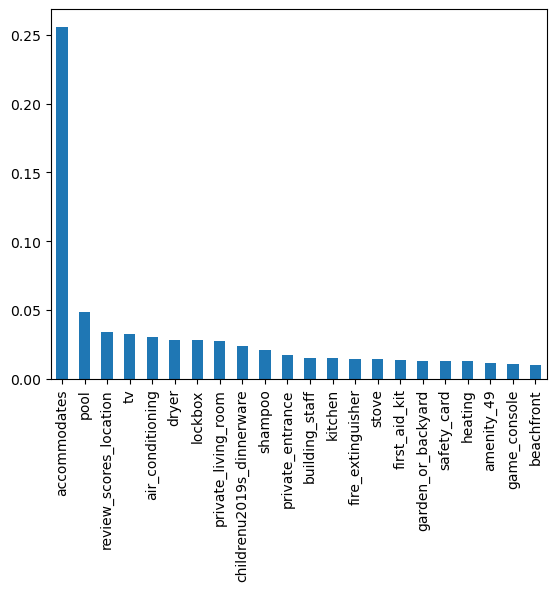

In [141]:
(pd.Series(model.feature_importances_, index=X.columns)
   .nlargest(22)
   .plot(kind='bar'))

#### Madrid

In [150]:
X = data_Madrid.drop(["price","city"], axis=1) 
y = data_Madrid["price"]

In [152]:
model = RandomForestRegressor(n_estimators=100, random_state=42)

In [154]:
model.fit(X,y)

RandomForestRegressor(random_state=42)

In [156]:
importance = model.feature_importances_

In [158]:
filtered_index = []
for i,v in enumerate(importance):
    if v > 0.01:
        filtered_index.append(i)
        print("Feature: %0d, Score: %.3f " % (i,v) + "Column: " + X.columns[i])

Feature: 0, Score: 0.046 Column: review_scores_location
Feature: 1, Score: 0.300 Column: accommodates
Feature: 7, Score: 0.012 Column: air_conditioning
Feature: 36, Score: 0.014 Column: cable_tv
Feature: 56, Score: 0.026 Column: crib
Feature: 67, Score: 0.021 Column: dryer
Feature: 72, Score: 0.012 Column: elevator
Feature: 83, Score: 0.011 Column: family_kid_friendly
Feature: 84, Score: 0.012 Column: fire_extinguisher
Feature: 114, Score: 0.019 Column: heating
Feature: 121, Score: 0.011 Column: indoor_fireplace
Feature: 122, Score: 0.018 Column: internet
Feature: 128, Score: 0.034 Column: laptop_friendly_workspace
Feature: 132, Score: 0.011 Column: long_term_stays_allowed
Feature: 178, Score: 0.030 Column: room_darkening_shades
Feature: 179, Score: 0.010 Column: safety_card
Feature: 181, Score: 0.012 Column: shampoo
Feature: 193, Score: 0.017 Column: smoking_allowed
Feature: 218, Score: 0.012 Column: washer


<Axes: >

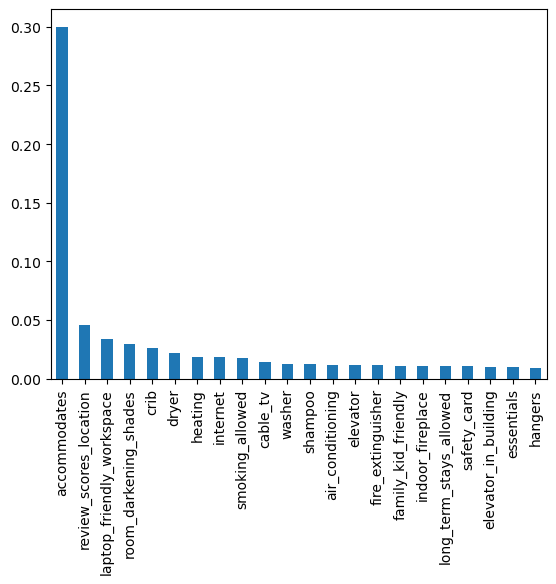

In [160]:
(pd.Series(model.feature_importances_, index=X.columns)
   .nlargest(22)
   .plot(kind='bar'))

#### Sevilla

In [162]:
X = data_Sevilla.drop(["price","city"], axis=1) 
y = data_Sevilla["price"]

In [164]:
model = RandomForestRegressor(n_estimators=100, random_state=42)

In [166]:
model.fit(X,y)

RandomForestRegressor(random_state=42)

In [168]:
importance = model.feature_importances_

In [170]:
filtered_index = []
for i,v in enumerate(importance):
    if v > 0.01:
        filtered_index.append(i)
        print("Feature: %0d, Score: %.3f " % (i,v) + "Column: " + X.columns[i])

Feature: 0, Score: 0.077 Column: review_scores_location
Feature: 1, Score: 0.179 Column: accommodates
Feature: 2, Score: 0.014 Column: 24_hour_check_in
Feature: 10, Score: 0.014 Column: amenity_50
Feature: 26, Score: 0.010 Column: bed_linens
Feature: 55, Score: 0.016 Column: cooking_basics
Feature: 56, Score: 0.022 Column: crib
Feature: 83, Score: 0.015 Column: family_kid_friendly
Feature: 84, Score: 0.021 Column: fire_extinguisher
Feature: 87, Score: 0.025 Column: first_aid_kit
Feature: 96, Score: 0.018 Column: free_parking_on_premises
Feature: 98, Score: 0.045 Column: free_street_parking
Feature: 106, Score: 0.014 Column: gym
Feature: 107, Score: 0.019 Column: hair_dryer
Feature: 109, Score: 0.021 Column: handheld_shower_head
Feature: 110, Score: 0.012 Column: hangers
Feature: 115, Score: 0.041 Column: high_chair
Feature: 116, Score: 0.010 Column: host_greets_you
Feature: 118, Score: 0.022 Column: hot_water
Feature: 123, Score: 0.013 Column: iron
Feature: 124, Score: 0.017 Column: ke

<Axes: >

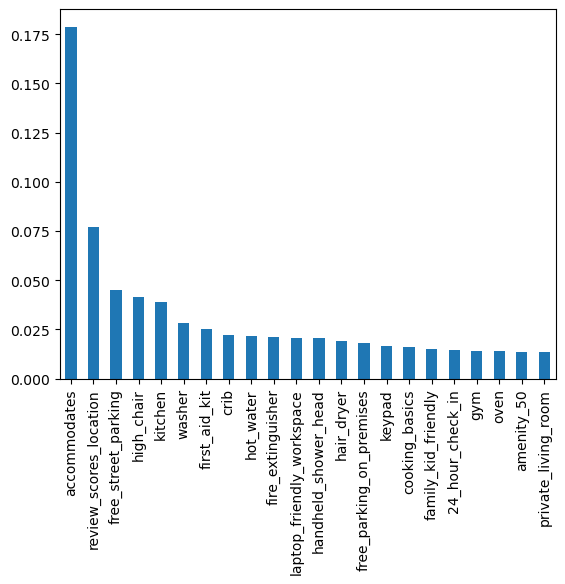

In [172]:
(pd.Series(model.feature_importances_, index=X.columns)
   .nlargest(22)
   .plot(kind='bar'))

#### Barcelona

#### Girona

#### Valencia

#### Mallorca

#### Menorca

# Data cleaning mapping

In [17]:
failed_text = []
for i in data['neighbourhood_name']:
    if i.__contains__("�"):
        failed_text.append(i)


In [18]:
x = pd.Series(failed_text) 
b = list(dict.fromkeys(x))
b

/var/folders/xb/_90p7jys6sq1w2hkc4td6hv80000gn/T/ipykernel_59247/2928171277.py:1: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  x = pd.Series(failed_text)


[]

In [19]:
name_mapping = {
    'C�rmenes': 'Cármenes',
    'Torroella de Fluvi�': 'Torroella de Fluvià',
    "el Camp d'en Grassot i Gr�cia Nova": "el Camp d'en Grassot i Gràcia Nova",
    'Alc�dia': 'Alcúdia',
    "Castell� d'Emp�ries": "Castelló d'Empúries",
    'Ciudad Jard�n': 'Ciudad Jardín',
    'la Vila de Gr�cia': 'la Vila de Gràcia',
    'Ni�o Jes�s': 'Niño Jesús',
    'la Sagrada Fam�lia': 'la Sagrada Família',
    'el Putxet i el Farr�': 'el Putxet i el Farró',
    'el Barri G�tic': 'el Barri Gòtic',
    'S�ller': 'Sóller',
    'Santany�': 'Santanyí',
    'la Vila Ol�mpica del Poblenou': 'la Vila Olímpica del Poblenou',
    'San Ferm�n': 'San Fermín',
    'Llub�': 'Llubí',
    'San Juli�n': 'San Julián',
    'San Bartolom�': 'San Bartolomé',
    'Calvi�': 'Calvià',
    'Pollen�a': 'Pollença',
    'Encarnaci�n, Regina': 'Encarnación, Regina',
    'Cadaqu�s': 'Cadaqués',
    'Mah�n': 'Mahón',
    'Sarri�': 'Sarrià',
    'Palam�s': 'Palamós',
    'Celr�': 'Celrà',
    'Torroella de Montgr�': 'Torroella de Montgrí',
    'Can Bar�': 'Can Baró',
    'Arg�elles': 'Argüelles',
    'Llan��': 'Llançà',
    'Pac�fico': 'Pacífico',
    'Proven�als del Poblenou': 'Provençals del Poblenou',
    'Marratx�': 'Marratxí',
    'Sant Feliu de Gu�xols': 'Sant Feliu de Guíxols',
    'Diagonal Mar i el Front Mar�tim del Poblenou': 'Diagonal Mar i el Front Marítim del Poblenou',
    'Santa Mar�a del Cam�': 'Santa María del Camí',
    'Pont�s': 'Pontós',
    'Le�n XIII, Los Naranjos': 'León XIII, Los Naranjos',
    'Sant Lloren� des Cardassar': 'Sant Llorenç des Cardassar',
    'Sant Llu�s': 'Sant Lluís',
    'Sant Gen�s dels Agudells': 'Sant Genís dels Agudells',
    'Art�': 'Artà',
    'el Baix Guinard�': 'el Baix Guinardó',
    'Tortell�': 'Tortellà',
    'Alar�': 'Alaró',
    'Hispanoam�rica': 'Hispanoamérica',
    'Cornell� del Terri': 'Cornellà del Terri',
    'B�ger': 'Búger',
    'Llad�': 'Lladó',
    'Palau de Santa Eul�lia': 'Palau de Santa Eulàlia',
    'el Congr�s i els Indians': 'el Congrés i els Indians',
    'el Bes�s i el Maresme': 'el Besòs i el Maresme',
    'Dey�': 'Deià',
    'Casco Hist�rico de Vallecas': 'Casco Histórico de Vallecas',
    'Carretera de Carmona, Mar�a Auxiliadora, Fontanal': 'Carretera de Carmona, María Auxiliadora, Fontanal',
    'Ur�s': 'Urús',
    'Sant Mart� Vell': 'Sant Martí Vell',
    'Vila�r': 'Vilafran',
    'Vidr�': 'Vidré',
    'Sant Mart� de Proven�als': 'Sant Martí de Provençals',
    'el Guinard�': 'el Guinardó',
    'Concepci�n': 'Concepción',
    'Bescan�': 'Bescanó',
    'Jer�nimos': 'Jerónimos',
    'Moscard�': 'Moscardó',
    'Doctor Barraquer, G. Renfe, Policl�nico': 'Doctor Barraquer, G. Renfe, Policlínico',
    'Seriny�': 'Serinyà',
    "Cru�lles, Monells i Sant Sadurn� de l'Heura": "Cruïlles, Monells i Sant Sadurní de l'Heura",
    'Montu�ri': 'Montuïri',
    'el Tur� de la Peira': 'el Turó de la Peira',
    'Ventall�': 'Ventalló',
    'Fontarr�n': 'Fontarrón',
    'San Andr�s': 'San Andrés',
    'El Roc�o': 'El Rocío',
    "Bellcaire d'Empord�": "Bellcaire d'Empordà",
    'Nervi�n': 'Nervión',
    'Santa Eug�nia': 'Santa Eugènia',
    'Besal�': 'Besalú',
    'Nueva Espa�a': 'Nueva España',
    'Ull�': 'Ullà',
    'Pe�agrande': 'Peñagrande',
    'Casco Hist�rico de Barajas': 'Casco Histórico de Barajas',
    'San Jos� Obrero': 'San José Obrero',
    'La Palmilla, Doctor Mara��n': 'La Palmilla, Doctor Marañón',
    'Barrio Le�n': 'Barrio León',
    'Puigcerd�': 'Puigcerdà',
    'El Tard�n, El Carmen': 'El Tardón, El Carmen',
    'Hell�n': 'Hellín',
    'Opa�el': 'Opañel',
    'Sant Mart� de Ll�mena': 'Sant Martí de Llémena',
    'Foix�': 'Foixà',
    'Casco Hist�rico de Vic�lvaro': 'Casco Histórico de Vicálvaro',
    "La Tallada d'Empord�": "La Tallada d'Empordà",
    'Vallfogona de Ripoll�s': 'Vallfogona de Ripollès',
    'Campdev�nol': 'Campdevànol',
    'Rab�s': 'Rabós',
    'Regenc�s': 'Regencós',
    'Zof�o': 'Zofío',
    'Sant Pau de Seg�ries': 'Sant Pau de Segúries',
    'Torre Bar�': 'Torre Baró',
    'Tiro de L�nea, Santa Genoveva': 'Tiro de Línea, Santa Genoveva',
    'Tim�n': 'Timón',
    'Ma�anet de la Selva': 'Maçanet de la Selva',
    'Entrev�as': 'Entrevías',
    'Parlav�': 'Parlavà',
    'Sant Juli� de Ramis': 'Sant Julià de Ramis',
    'Mai� de Montcal': 'Maçanet de Montcal',
    'B�scara': 'Bàscara',
    'Arb�cies': 'Arbúcies',
    'Vilaju�ga': 'Vilajuïga'
}

In [20]:
data["neighbourhood_name"] = data["neighbourhood_name"].replace(name_mapping)

In [21]:
data["neighbourhood_name"]

0                                Centro
1                              Cármenes
2                           San Vicente
3       L'Antiga Esquerra De L'Eixample
4                                 Quart
                     ...               
7529                        Sant Antoni
7530                             Arenal
7531                           Felanitx
7532            Provençals Del Poblenou
7533                              Roses
Name: neighbourhood_name, Length: 7534, dtype: object

In [22]:
data['neighbourhood_district'] = data['neighbourhood_district'].fillna("")
data['neighbourhood_district']

0                    
1              Latina
2       Casco Antiguo
3            Eixample
4                    
            ...      
7529         Eixample
7530    Casco Antiguo
7531                 
7532       Sant Martí
7533                 
Name: neighbourhood_district, Length: 7534, dtype: object

In [23]:
failed_text_02=[]
for i in data['neighbourhood_district']:
    if i.__contains__("�"):
        failed_text_02.append(i)

failed_text_02

[]

In [24]:
y = pd.Series(failed_text_02) 
c = list(dict.fromkeys(y))
c

/var/folders/xb/_90p7jys6sq1w2hkc4td6hv80000gn/T/ipykernel_59247/3621039225.py:1: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  y = pd.Series(failed_text_02)


[]

In [25]:
name_mapping_district = {
    'Sant Mart�': 'Sant Martí',
    'Gr�cia': 'Gràcia',
    'Sarri�-Sant Gervasi': 'Sarrià-Sant Gervasi',
    'Sants-Montju�c': 'Sants-Montjuïc',
    'Horta-Guinard�': 'Horta-Guinardó',
    'Chamart�n': 'Chamartín',
    'Tetu�n': 'Tetuán',
    'Nervi�n': 'Nervión',
    'Chamber�': 'Chamberí',
    'Vic�lvaro': 'Vicálvaro'
}

In [26]:
data["neighbourhood_district"] = data["neighbourhood_district"].replace(name_mapping_district)

In [27]:
data["neighbourhood_district"].value_counts()

                     2927
Centro                829
Eixample              803
Ciutat Vella          551
Casco Antiguo         277
                     ... 
Cerro - Amate           3
Macarena - Norte        2
Poblats De L'Oest       1
Vicálvaro               1
Poblats Del Nord        1
Name: neighbourhood_district, Length: 61, dtype: int64